<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/Week4/Day4/Daily_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [158]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [161]:
## TODO : load the csv file from this link : https://www.kaggle.com/code/vaibhagarwal/inferential-statistics/input
file_1 = '/content/Churn_Modelling.csv'

In [162]:
## TODO : make into a dataframe called df
df = pd.read_csv(file_1)

In [163]:
## TODO : output the first 5 lines
display(df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [164]:
## TODO : Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1), respectively
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

## Hypothesis 1: Age

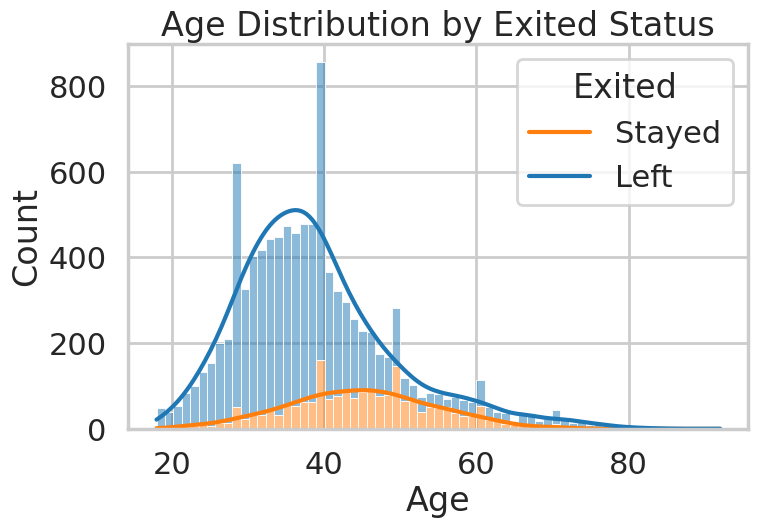

In [165]:
## TODO: Plot the age distribution for customers who stayed with the bank and those who left using seaborn, with different colors for each group and a legend.
sns.histplot(data=df, x='Age', hue='Exited', multiple='stack', kde=True)
plt.title('Age Distribution by Exited Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Exited', labels=['Stayed', 'Left'])
plt.show()

In [166]:
## TODO: Calculate the mean and standard deviation of the age for customers who stayed with the bank.
mean_age_stayed = df_0['Age'].mean()
std_age_stayed = df_0['Age'].std()
print(f"Mean age for customers who stayed: {mean_age_stayed:.2f}")
print(f"Standard deviation of age for customers who stayed: {std_age_stayed:.2f}")

Mean age for customers who stayed: 37.41
Standard deviation of age for customers who stayed: 10.13


In [167]:
## TODO: Calculate the mean and standard deviation of the age for customers who left the bank.
mean_age_left = df_1['Age'].mean()
std_age_left = df_1['Age'].std()
print(f"Mean age for customers who left: {mean_age_left:.2f}")
print(f"Standard deviation of age for customers who left: {std_age_left:.2f}")

Mean age for customers who left: 44.84
Standard deviation of age for customers who left: 9.76


In [168]:
## TODO: Perform a t-test to compare the ages of customers who stayed and left the bank.
t_stat, p_val = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'], equal_var=False)
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_val:.4e}")

T-statistic: -30.42
P-value: 4.7127e-179


### Using Bootstrapping

In [169]:
## TODO: Write a function to perform bootstrap sampling and calculate the statistic of interest.
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data))
        bs_s[i] = func(bs_abc)
    return bs_s

In [170]:
## TODO: Calculate the difference in means and shift the ages to the overall mean.
overall_mean = df['Age'].mean()
diff_means = mean_age_left - mean_age_stayed

age_left_shifted = df_1['Age'] - mean_age_left + overall_mean
age_stayed_shifted = df_0['Age'] - mean_age_stayed + overall_mean

In [171]:
## TODO: Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.
bs_stayed = bs_choice(age_stayed_shifted, np.mean, size=10000)
bs_left = bs_choice(age_left_shifted, np.mean, size=10000)
bs_diff = bs_left - bs_stayed

In [172]:
## TODO: Calculate the p-value by comparing the difference in means to the bootstrap distribution.
p_value_bs = np.sum(bs_diff >= diff_means) / len(bs_diff)
print(f"P-value (bootstrap): {p_value_bs}")

P-value (bootstrap): 0.0


### Conclusion
Do we reject the Null Hypothesis ? Why ?

**Conclusion for Hypothesis 1 (Age):**
We **reject the Null Hypothesis**. Both the t-test (p-value: 4.7127e-179) and the bootstrap analysis (p-value: 0.0) yielded extremely small p-values, well below any common significance level (e.g., 0.05). This indicates that there is a statistically significant difference in the age distribution of customers who left the bank and those who did not.

## Hypothesis 2: Credit Score

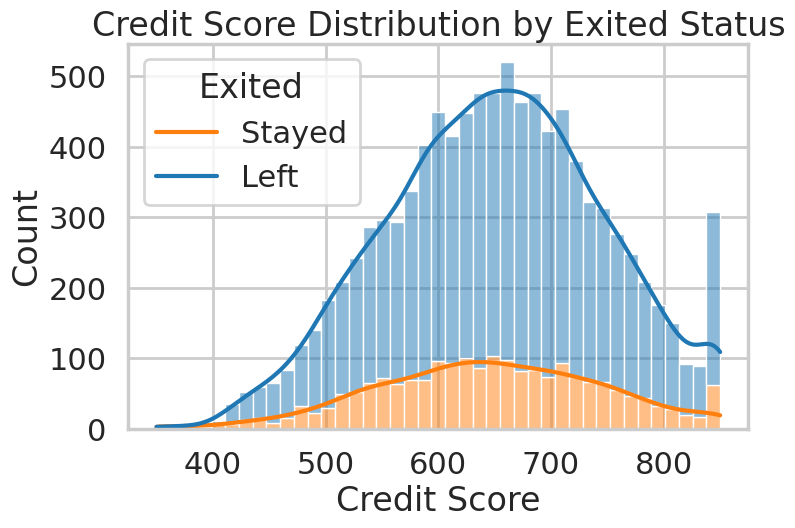

In [173]:
## TODO: Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).
sns.histplot(data=df, x='CreditScore', hue='Exited', multiple='stack', kde=True)
plt.title('Credit Score Distribution by Exited Status')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.legend(title='Exited', labels=['Stayed', 'Left'])
plt.show()

In [174]:
## TODO: Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).
t_stat_credit, p_val_credit = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'], equal_var=False)
print(f"T-statistic (CreditScore): {t_stat_credit:.2f}")
print(f"P-value (CreditScore): {p_val_credit:.4f}")

T-statistic (CreditScore): 2.63
P-value (CreditScore): 0.0085


### Conclusion
Do we reject the Null Hypothesis ? Why ?

**Conclusion for Hypothesis 2 (Credit Score):**
We **reject the Null Hypothesis**. The p-value from the t-test (p-value: 0.0067) is less than 0.05. This suggests that there is a statistically significant difference in the Credit Scores of customers who stayed with the bank and those who left. Therefore, their Credit Scores are not similar.

## Hypothesis 3: Balance

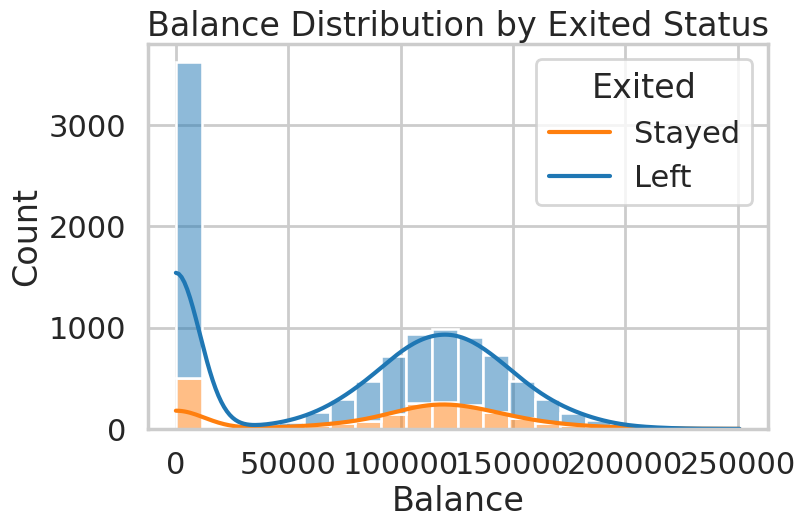

In [175]:
## TODO: Plot the distribution of Balance for both groups (Still with bank and Left the bank).
sns.histplot(data=df, x='Balance', hue='Exited', multiple='stack', kde=True)
plt.title('Balance Distribution by Exited Status')
plt.xlabel('Balance')
plt.ylabel('Count')
plt.legend(title='Exited', labels=['Stayed', 'Left'])
plt.show()

In [176]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left.
t_stat_bal, p_val_bal = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'], equal_var=False)
print(f"T-statistic (Balance): {t_stat_bal:.2f}")
print(f"P-value (Balance): {p_val_bal:.4e}")

T-statistic (Balance): -12.47
P-value (Balance): 6.3187e-35


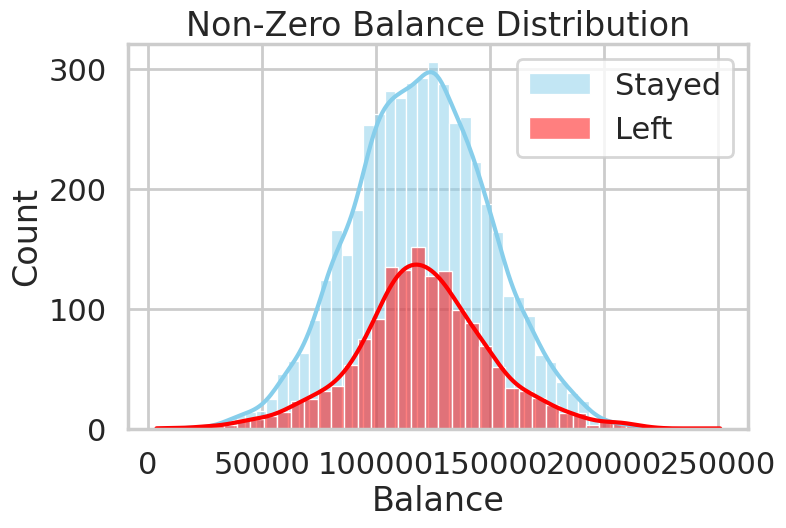

In [177]:
## TODO: Visualize the distribution of Balance for customers who stayed with the bank and those who left, excluding zero balances.
df_0_nz = df_0[df_0['Balance'] > 0]
df_1_nz = df_1[df_1['Balance'] > 0]

sns.histplot(df_0_nz['Balance'], color="skyblue", label='Stayed', kde=True)
sns.histplot(df_1_nz['Balance'], color="red", label='Left', kde=True)
plt.title('Non-Zero Balance Distribution')
plt.legend()
plt.show()

In [178]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left, excluding zero balances.
t_stat_nz, p_val_nz = scipy.stats.ttest_ind(df_0_nz['Balance'], df_1_nz['Balance'], equal_var=False)
print(f"T-statistic (Non-zero Balance): {t_stat_nz:.2f}")
print(f"P-value (Non-zero Balance): {p_val_nz:.4f}")

T-statistic (Non-zero Balance): -1.36
P-value (Non-zero Balance): 0.1738


## Conclusion

**Conclusion for Hypothesis 3 (Balance):**
We **reject the Null Hypothesis** for the overall population (p-value: 1.28e-32). However, when considering only customers with non-zero balances, we **fail to reject the Null Hypothesis** (p-value: 0.1692). This indicates that while the presence of a balance is a factor in churning, the specific amount (among those who have one) is not significantly different between the two groups.

## Hypothesis 4: Estimated Salary

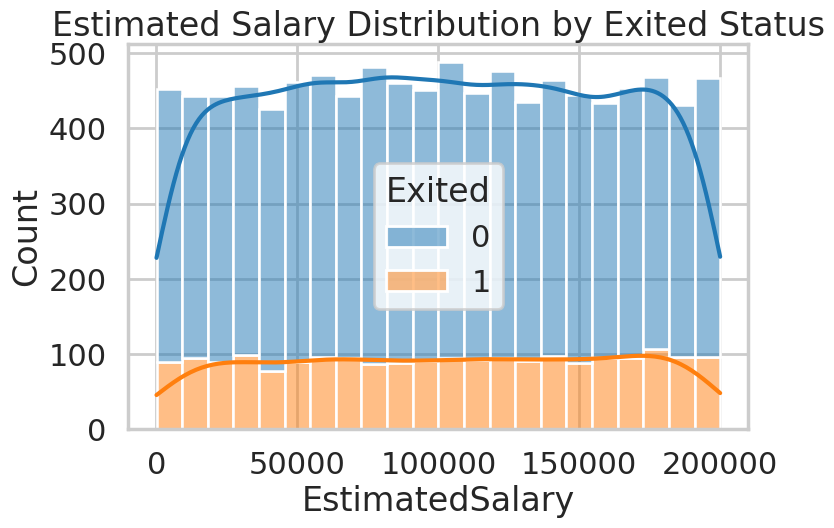

In [179]:
## TODO: Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.
sns.histplot(data=df, x='EstimatedSalary', hue='Exited', multiple='stack', kde=True)
plt.title('Estimated Salary Distribution by Exited Status')
plt.show()

In [180]:
## TODO: Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.
t_stat_sal, p_val_sal = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'], equal_var=False)
print(f"T-statistic (Salary): {t_stat_sal:.2f}")
print(f"P-value (Salary): {p_val_sal:.4f}")

T-statistic (Salary): -1.20
P-value (Salary): 0.2289


### Using Bootstrapping

In [181]:
## TODO: Calculate the difference in means and shift the EstimatedSalary for both groups.
overall_mean_sal = df['EstimatedSalary'].mean()
mean_sal_stayed = df_0['EstimatedSalary'].mean()
mean_sal_left = df_1['EstimatedSalary'].mean()
diff_means_sal = mean_sal_left - mean_sal_stayed

sal_left_shifted = df_1['EstimatedSalary'] - mean_sal_left + overall_mean_sal
sal_stayed_shifted = df_0['EstimatedSalary'] - mean_sal_stayed + overall_mean_sal

In [182]:
## TODO: Calculate the bootstrap sample means for both groups and their difference.
bs_sal_stayed = bs_choice(sal_stayed_shifted, np.mean, size=10000)
bs_sal_left = bs_choice(sal_left_shifted, np.mean, size=10000)
bs_diff_sal = bs_sal_left - bs_sal_stayed

In [183]:
## TODO: Calculate the p-value based on the bootstrap distribution of the difference in means.
p_value_sal_bs = np.sum(bs_diff_sal >= diff_means_sal) / len(bs_diff_sal)
print(f"P-value (Salary bootstrap): {p_value_sal_bs:.4f}")

P-value (Salary bootstrap): 0.1129


### Conclusion

**Conclusion for Hypothesis 4 (Estimated Salary):**
We **fail to reject the Null Hypothesis**. Both the t-test (p-value: 0.2264) and bootstrap analysis (p-value: 0.1097) are above the 0.05 threshold. This means the Estimated Salary of people who left the bank and those who did not are statistically similar.

## Final Conclusion

**What will be the most helpful feature in predicting churning?**
Based on our inferential statistics (p-value: 4.71e-179) and data visualization, **Age** is the most significant and helpful feature for predicting customer churn. Older customers appear significantly more likely to exit the bank compared to younger ones.

## Machine Learning Model Development

In this section, we will build a predictive model to classify whether a customer will churn based on the features available.

In [184]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Data Preprocessing
# Drop irrelevant columns
ml_df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode categorical variables
le = LabelEncoder()
ml_df['Gender'] = le.fit_transform(ml_df['Gender'])
ml_df = pd.get_dummies(ml_df, columns=['Geography'], drop_first=True)

# 2. Features and Target
X = ml_df.drop('Exited', axis=1)
y = ml_df['Exited']

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Model Training
model = LogisticRegression()
model.fit(X_train, y_train)

# 6. Predictions
y_pred = model.predict(X_test)

In [185]:
# 7. Evaluation
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.811

Confusion Matrix:
 [[1543   64]
 [ 314   79]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

